# This notebook shows how to compute the spin Berry curvature
### Import the necessary libraries

In [1]:
%matplotlib inline
import re
import numpy as np
import matplotlib.pyplot as plt

from elkpy.structure import Structure
from elkpy.parsers import spin_hall, optical
from elkpy.parsers.spin import compute_spin_operator

### The spin current operator
Spin transport is driven by the symmetrized product of a spin and a velocity,
$$ J^{s}_{a}=\tfrac12\{S_s,v_a\}, \qquad \Omega^{s}_{ab}=-2\,\mathrm{Im}\sum_{n\in W}\sum_{m\notin W}\frac{\langle n|J^{s}_{a}|m\rangle\langle m|v_b|n\rangle}{(\varepsilon_n-\varepsilon_m)^2} $$
symmetrized because $S_s$ and $v_a$ need not commute. Integrating $\Omega^s$ over occupied states gives the intrinsic spin Hall conductivity.

In [2]:
A = 2.46 / 0.529177210903  # Bohr, monolayer graphene
AVEC = [(A, 0.0, 0.0), (-A / 2, A * 3 ** 0.5 / 2, 0.0), (0.0, 0.0, 20.0)]
SPECIES = {"C": [(0.0, 0.0, 0.5), (1 / 3, 2 / 3, 0.5)]}

graphene = Structure(AVEC, SPECIES).get_calculation(
    "_scratch/graphene_spin_hall", xc="PW", ngridk=(6, 6, 1), rgkmax=7.0,
    spinorb=True, soc_scale={"C": 3000.0},  # real carbon SOC is ~microeV
    # the Kubo sum runs over states ABOVE the window -- with Elk's default handful
    # of empty states there is almost nothing to sum and the result collapses
    extra_blocks={"nempty": [12]},
)
graphene.get_energy()

-75.938977195128

### One diagonalisation, both operators
$S_z$ is built from `evecsv` and $v_a$ from the momentum matrix elements. Multiplying them is only meaningful if both come from the **same** diagonalisation — two independent ones may resolve a degenerate multiplet in different bases, which would corrupt the product while leaving every Hermiticity check intact. The `MOMENTUM` query therefore returns `evecsv` alongside `pmat`.

In [3]:
W0, W1 = 1, 6  # a gapped band group

def curvatures(session, k):
    m = session.momentum(k)          # energies, evecsv AND pmat: ONE diagonalisation
    nstsv = m.evecsv.shape[0]
    # S_z built from that same evecsv, so it shares an eigenbasis with pmat
    sz = compute_spin_operator(m.evecsv, nstsv // 2, 1, nstsv)["sz"]
    spin = spin_hall.spin_berry_curvature(m.energies, m.pmat, sz, W0, W1)
    charge = optical.kubo_berry_curvature(m.energies, m.pmat, W0, W1)
    return spin, charge

K, KP = (1 / 3, 1 / 3, 0), (-1 / 3, -1 / 3, 0)
with graphene.eigenstate_session() as session:
    sK, cK = curvatures(session, K)
    sKp, cKp = curvatures(session, KP)
print(f"spin   Omega^s(K) = {sK:10.4f}   Omega^s(K') = {sKp:10.4f}")
print(f"charge Omega  (K) = {cK:10.2e}   Omega  (K') = {cKp:10.2e}")

spin   Omega^s(K) =    -0.3194   Omega^s(K') =    -0.3194
charge Omega  (K) =   2.01e-07   Omega  (K') =  -1.67e-07


### The two valleys agree in sign
Charge Berry curvature is **odd** under time reversal, $\Omega(-\mathbf{k})=-\Omega(\mathbf{k})$ — the antisymmetry every other valley quantity in these notebooks shows. Spin Berry curvature is **even**, because time reversal flips both the spin and the velocity. So $\Omega^s(K)=+\Omega^s(K')$, the opposite relation, and it is what an accidental exchange of the two operators could not produce.

In [4]:
def segment(a, b, n):
    a, b = np.array(a), np.array(b)
    return [tuple(a + (b - a) * t) for t in np.linspace(0, 1, n)]

G, M, Kp_img = (0, 0, 0), (0.5, 0, 0), (2 / 3, -1 / 3, 0)
segments = [segment(G, K, 8)] + [segment(a, b, 8)[1:] for a, b in [(K, M), (M, Kp_img), (Kp_img, G)]]
ticks = np.concatenate([[0], np.cumsum([len(s) for s in segments]) - 1])
path = sum(segments, [])

spin_path = []
with graphene.eigenstate_session() as session:
    for k in path:
        spin_path.append(curvatures(session, k)[0])
spin_path = np.array(spin_path)

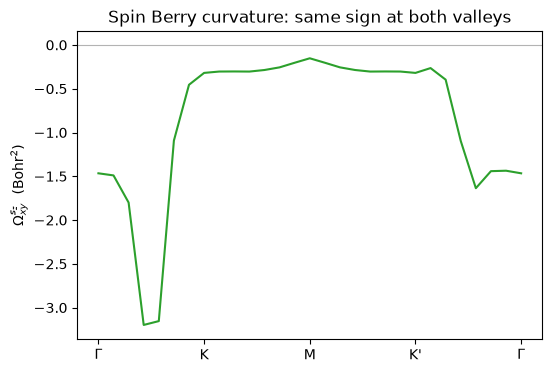

In [5]:
x = np.arange(len(path))
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(x, spin_path, "-", color="C2")
ax.axhline(0, color="0.7", lw=0.8)
ax.set_xticks(ticks)
ax.set_xticklabels([r"$\Gamma$", "K", "M", "K'", r"$\Gamma$"])
ax.set_ylabel(r"$\Omega^{s_z}_{xy}$  (Bohr$^2$)")
ax.set_title("Spin Berry curvature: same sign at both valleys")
plt.show()